In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

In [42]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,
        :DMedium_2 => Float64,
        :delta_2 => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)
        ll_2 = sqrt(DMedium_2 / delta_2)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mmb = 1.0 * besselk(0, r_eff / ll)

        mmc = 1.0 * besselk(0, r_eff / ll_2)

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - Nrec * log((1 + mmc / Ki) / (1 + mmc / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - Nrec * log((1 + mmc / Ki) / (1 + mmc / Ka)) - F0) / (- ε1)      #Energia lliure en estat adaptat


        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))     

        fx = vx
        fy = vy

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)     
    end,

    agentRule = quote
  

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end
        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end

        # xmin, xmax = simBox[1,1], simBox[1,2]
        # ymin, ymax = simBox[2,1], simBox[2,2]

        # if x <= xmin
        #     x = xmin + (xmin - x)
        #     theta = pi - theta
        # elseif x >= xmax
        #     x = xmax + (xmax-x)
        #     theta = pi - theta
        # end

        # if y >= ymax
        #     y = 2*ymax - y
        #     theta = 2*pi - theta
        # elseif y <= ymin
        #     y = 2*ymin - y
        #     theta = 2*pi - theta
        # end

    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
    # neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	delta_2 (Float64 model)
	K (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	DMedium_2 (Float64 model)
	ε2 (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin

In [8]:
com = Community(
    fixed_source,
    N=500,
    dt=0.01,
    simBox = [-200.0 200.0; -200.0 200.0],
    NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1


com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

# Attractant
# com.DMedium = 1.25 # n 8
# com.delta = 0.08
# com.DMedium = 2 # n 5
# com.delta = 0.05
# com.DMedium = 3.33 # n 3
# com.delta = 0.03
com.DMedium = 20 # n 0.5
com.delta = 0.005


# Repellant
# com.DMedium_2 = 20
# com.delta_2 = 0.005
# com.DMedium_2 = 1.25 # n 8
# com.delta_2 = 0.08
# com.DMedium_2 = 2 # n 5
# com.delta_2 = 0.05
com.DMedium_2 = 3.33 # n 3
com.delta_2 = 0.03

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
# com.x = 2.5*sqrt(com.DMedium/com.delta)
# com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 

500-element Vector{Bool}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [48]:
combinations = [ "p05_r75", "p05_r1", "p05_r2", "p05_r3", "p05_r5", "p05_r8"]
# combinations = ["p05", "p05_r025", "p075_r025", "p1_r025", "p2_r025"]

Dcvals_r = [13.33, 10.0, 5.0, 3.33, 2, 1.25]
dvals_r = [ 0.0075, 0.01, 0.02, 0.03, 0.05, 0.08]
Dcvals_p = [20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0]
dvals_p = [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,]


for i in 1:length(combinations)
    com = Community(
        fixed_source,
        N=500,
        dt=0.01,
        simBox = [-200.0 200.0; -200.0 200.0],
        NMedium = [200, 200]
    )

    m = 1/100
    g = 1/10000
    d = 1

    com.Dr_run = 0.062
    com.v = 10.0

    com.ωFrec = 1.3
    com.Ki = 0.0182
    com.Ka = 3.0
    com.Nrec = 6.0
    com.ε0   = 6.0
    com.ε1   = -1.0
    com.ε2   = 80
    com.ε3   = 80

    com.τm = 1

    com.α   = 6.0

    com.K = 2.0 

    com.Ky = 100.0
    com.Kz = 10.0
    com.Z = 5.0
    com.Yy = 0.1

    com.m = 1.        
    com.d = 1.        
    com.l = 3;

    #Attractant
    com.DMedium = Dcvals_p[i]
    com.delta = dvals_p[i]

    #Repellant
    com.DMedium_2 = Dcvals_r[i]
    com.delta_2 = dvals_r[i]

    com.x = rand(Uniform(com.simBox[1,:]...),com.N)
    com.y = rand(Uniform(com.simBox[2,:]...),com.N)

    com.theta = rand(Uniform(0,2π),com.N)

    com.methyl .= 0.0
    com.Yp .= com.K

    com.active .= true 

    outfile = "fsb_posneg_$(combinations[i]).jld2"
    println(outfile)
    steps = 25000

    loadToPlatform!(com, preallocateAgents=1000)

    jldopen(outfile, "w") do file

        # -------------------------
        # Metadata (written once)
        # -------------------------
        meta = JLD2.Group(file, "meta")

        meta["DMedium"] = com.DMedium
        meta["delta"] = com.delta

        # -------------------------
        # Main loop
        # -------------------------
        for step in 1:steps
            step!(com)

            if step%100 == 0

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)
                if step%5000 == 0
                    println(step)
                end
            end

        end
    end
end

fsb_posneg_p05_r75.jld2
5000
10000
15000
20000
25000
fsb_posneg_p05_r1.jld2
5000
10000
15000
20000
25000
fsb_posneg_p05_r2.jld2
5000
10000
15000
20000
25000
fsb_posneg_p05_r3.jld2
5000
10000
15000
20000
25000
fsb_posneg_p05_r5.jld2
5000
10000
15000
20000
25000
fsb_posneg_p05_r8.jld2
5000
10000
15000
20000
25000


In [9]:
outfile = "fsb_posneg_p05_r3.jld2"
steps = 25000

loadToPlatform!(com, preallocateAgents=1000)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")

    meta["DMedium"] = com.DMedium
    meta["delta"] = com.delta

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        if step%100 == 0

            stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)
            if step%5000 == 0
                println(step)
            end
        end

    end
end


5000
10000
15000
20000
25000


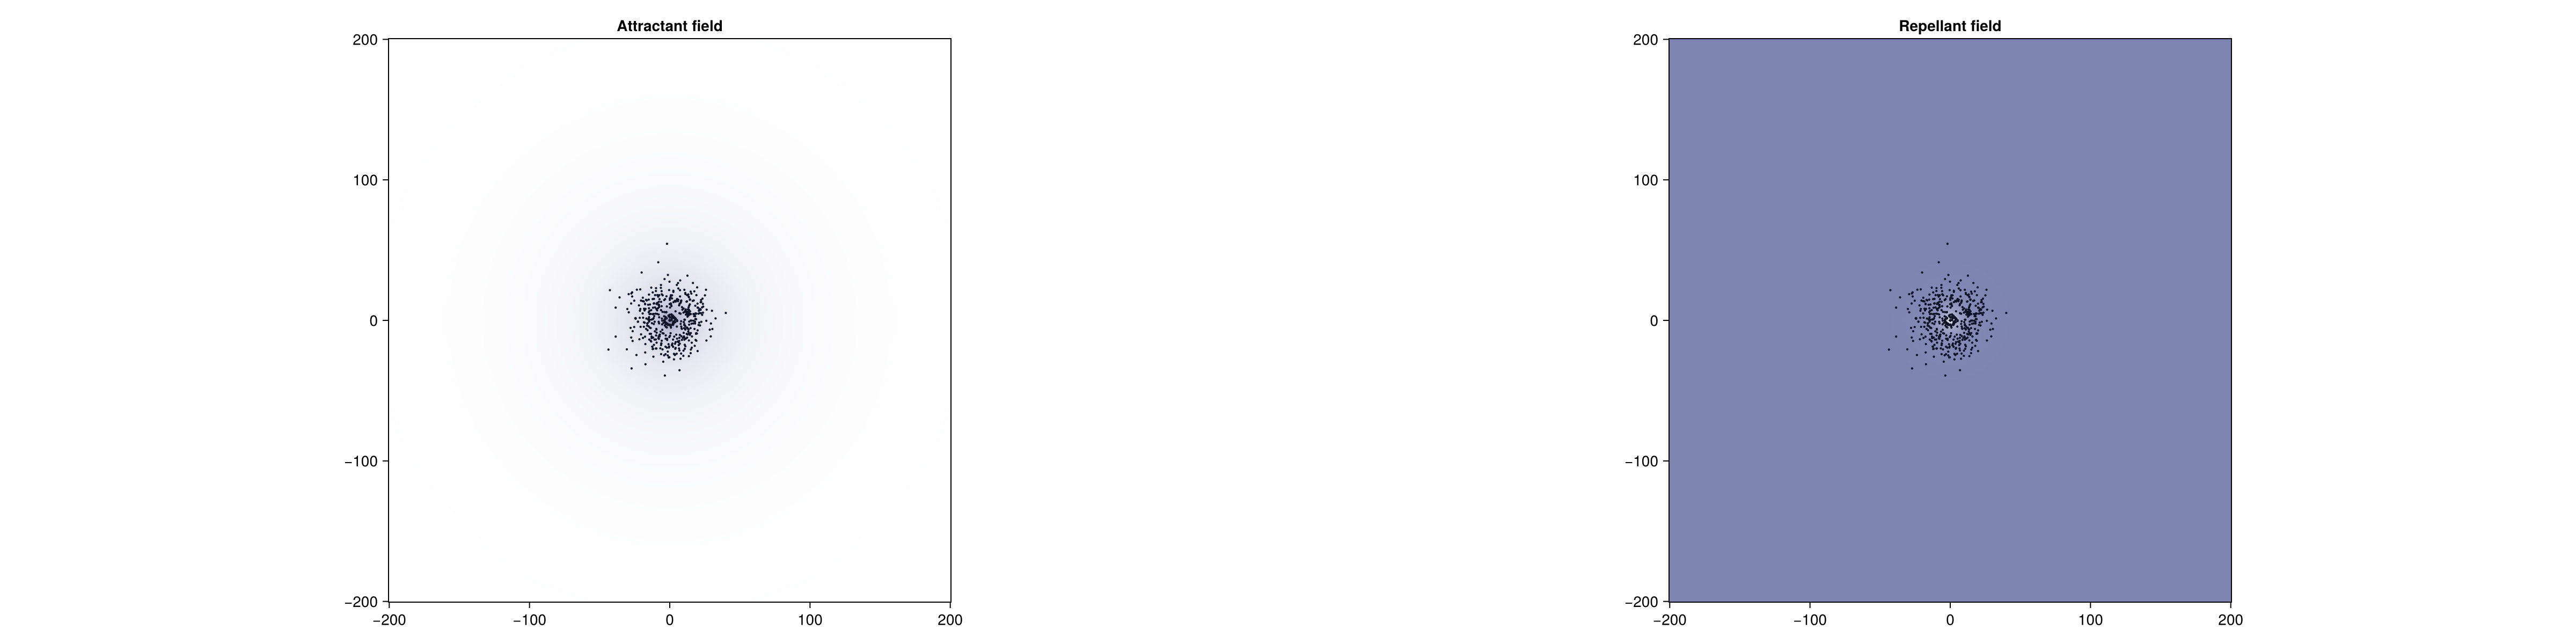

CairoMakie.Screen{IMAGE}


In [36]:
using CairoMakie
fig = Figure(size=(2400,600))

dark = colorant"#645986"
bac = colorant"#0E1428"
dark2 = colorant"#7D84B2"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
cmap = cgrad([white, dark2])
cmap2 = cgrad([dark2, white])

len = Int(200 + 200)
x_grid = range(-200, 200, length=len)
y_grid = range(-200, 200, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(20 / 0.005) #Attractant
λ2 = sqrt(3.33 / 0.03) #Repellant
r1 = sqrt.((X .- 0).^2 .+ (Y .- 0).^2)

mm_grid = @. 1.0 * besselk(0, r1 / λ)
mm_grid2 = @. 1.0 * besselk(0, r1 / λ2)

jldopen("fsb_posneg_p05_r1.jld2", "r") do file 


        x = Vector{Float64}(undef, 1)
        y = Vector{Float64}(undef, 1)

        ax = Axis(fig[1, 1], aspect=1, title = "Attractant field")
        ax2 = Axis(fig[1, 2], aspect=1, title = "Repellant field")

        g = file[@sprintf("step_%06d", 25000)]
        hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=cmap)
        hm = heatmap!(ax2, x_grid, y_grid, mm_grid2, colormap=cmap2)

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3

        for i in 1:length(x)
            scatter!(ax, x[i], y[i], color=bac, markersize=3)
            scatter!(ax2, x[i], y[i], color=bac, markersize=3)
        end
      
end

display(fig)

In [37]:
save("Plots/Fixed_source_model/Posneg/p05_r1_1.pdf", fig)

CairoMakie.Screen{PDF}


5.3002234435717314.201804332596535


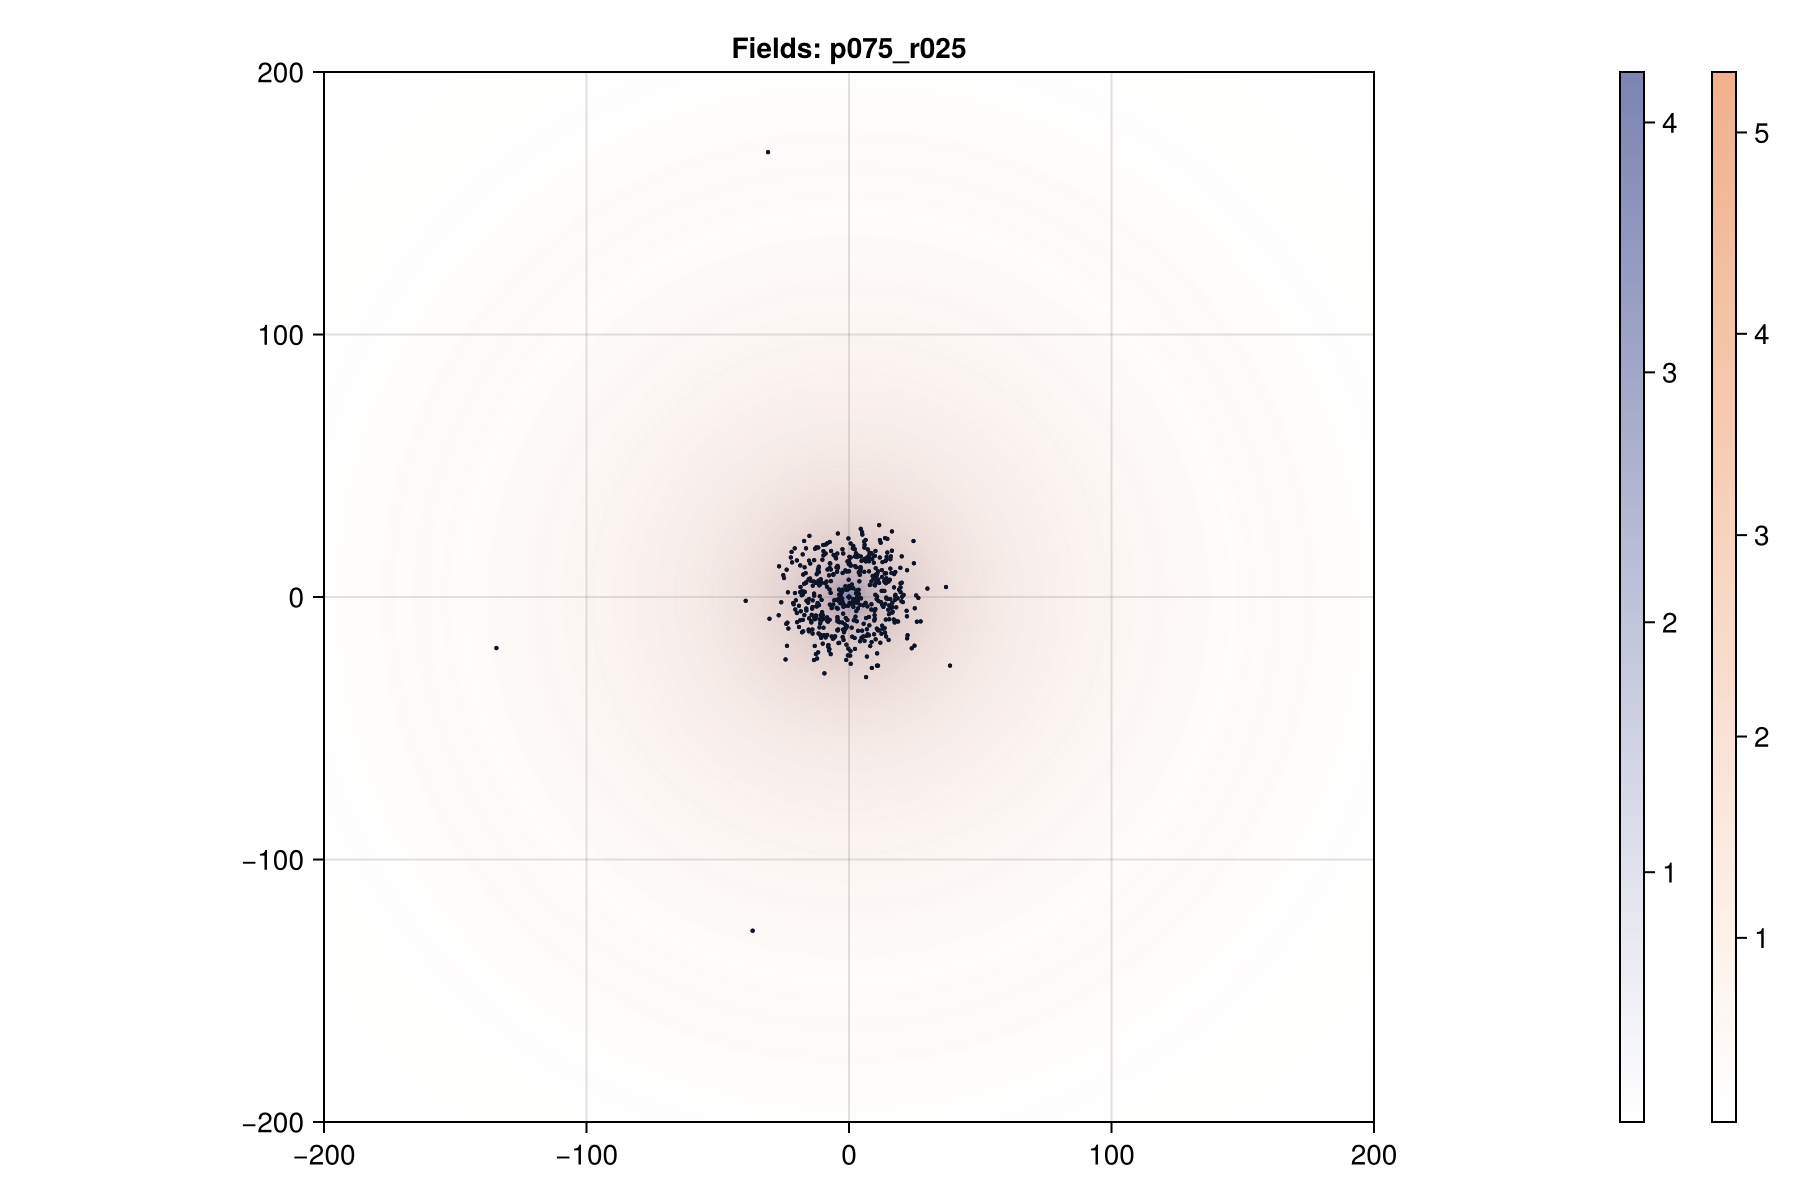

In [26]:
using CairoMakie

# combinations = ["p05_r025"]
combinations = ["p05", "p05_r025", "p075_r025", "p1_r025", "p2_r025"]
Dcvals_p = [20.0, 20.0, 13.33, 10.0, 5.0]
dvals_p = [0.005, 0.005, 0.0075, 0.01, 0.02]
Dcvals_r = [0.0, 40, 40, 40, 40]
dvals_r = [0.0, 0.0025, 0.0025, 0.0025, 0.0025]
bac = colorant"#0E1428"

# for i in 1:1
i = 3
    filename = "fsb_posneg_$(combinations[i]).jld2"
    Dc_r = Dcvals_r[i]
    Dc_a = Dcvals_p[i]
    d_r = dvals_r[i]
    d_a = dvals_p[i]


    fig = Figure(size=(900,600))

    len = Int(200 + 200)
    x_grid = range(-200, 200, length=len)
    y_grid = range(-200, 200, length=len)

    X, Y = meshgrid(x_grid, y_grid)

    λ = sqrt(Dc_a / d_a) #Attractant
    λ2 = sqrt(Dc_r / d_r) #Repellant
    r1 = sqrt.((X .- 0).^2 .+ (Y .- 0).^2)

    mm_grid = @. 1.0 * besselk(0, r1 / λ)
    mm_grid2 = @. 1.0 * besselk(0, r1 / λ2)

    maxt = maximum(mm_grid) + maximum(mm_grid2)
    op_a = maximum(mm_grid) / maxt
    op_r = maximum(mm_grid2) / maxt

    println(maximum(mm_grid2), "", maximum(mm_grid))
    c_min = RGBA(125/255, 132/255, 178/255, 0.0)  # transparent
    c_max = RGBA(125/255, 132/255, 178/255, 1)  # opaque
    c_map = cgrad([c_min, c_max])

    r_max = RGBA(0.9059, 0.4824, 0.2353, 0.6)  
    r_min = RGBA(0.9059, 0.4824, 0.2353, 0.0)  
    r_map = cgrad([r_min, r_max])

    jldopen(filename, "r") do file 


            x = Vector{Float64}(undef, 1)
            y = Vector{Float64}(undef, 1)

            ax = Axis(fig[1, 1], aspect=1, title = "Fields: $(combinations[i])")

            g = file[@sprintf("step_%06d", 25000)]
            hm2 = heatmap!(ax, x_grid, y_grid, mm_grid2, colormap=r_map, label = "Repellant")

            hm1 = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=c_map, label = "Attractant")
            # hm2 = heatmap!(ax, x_grid, y_grid, mm_grid2, colormap=r_map, label = "Repellant")

            x = g["x"]
            y = g["y"]
            theta = g["theta"]
            l = 3

            for i in 1:length(x)
                scatter!(ax, x[i], y[i], color=bac, markersize=3)
                scatter!(ax, x[i], y[i], color=bac, markersize=3)
            end
            xlims!(ax, -200, 200)
            ylims!(ax, -200, 200)
            Colorbar(fig[1,2], hm1)
            Colorbar(fig[1,3], hm2)
        
    end
    # save("Plots/Fixed_source_model/Posneg/$(combinations[i])_2.pdf", fig)

# end
fig

In [28]:
save("Plots/Fixed_source_model/Posneg/p075_r025_bar.pdf", fig)

CairoMakie.Screen{PDF}


# Probabilitat escape

p05_r025: 0
p075_r025: 9
p1_r025: 46
p2_r025: 151
p3_r025: 154
p5_r025: 182
p8_r025: 197


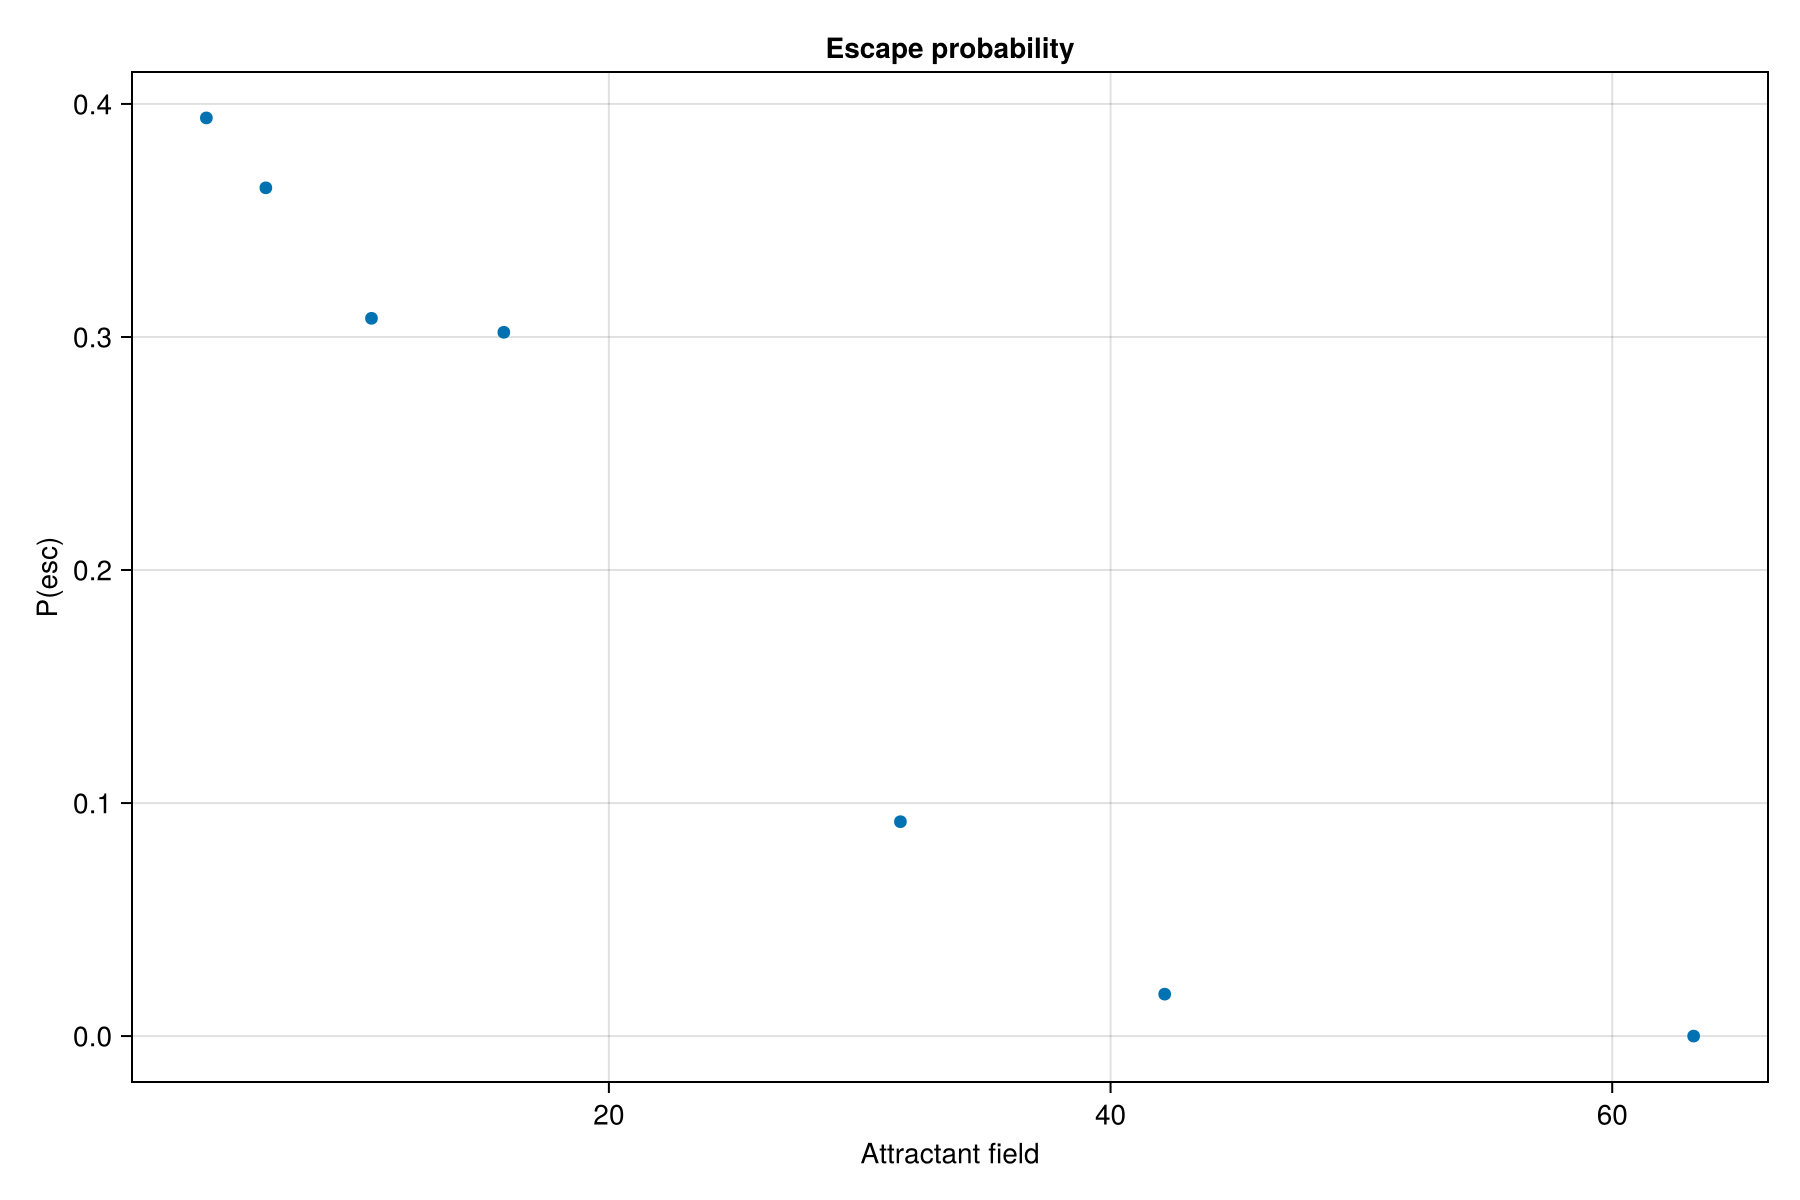

In [40]:
combinations = ["p05_r025", "p075_r025", "p1_r025", "p2_r025", "p3_r025", "p5_r025", "p8_r025"]
p_esc = []
for i in 1:length(combinations)
    filename = "fsb_posneg_$(combinations[i]).jld2"
    counts = 0
    jldopen(filename, "r") do file
        g = file[@sprintf("step_%06d", 25000)]
        x = g["x"]
        y = g["y"]
        for agent in 1:500
            x1 = x[agent]
            y1 = y[agent]
            if x1 > 200 || y1 > 200 || x1 < -200 || y1 < -200
                counts += 1
            end
        end
    end
    push!(p_esc, (counts / 500))
    println("$(combinations[i]): $counts")
end

field_atr = []
Dcvals_p = [20.0, 13.33, 10.0, 5.0, 3.33, 2, 1.25]
dvals_p = [0.005, 0.0075, 0.01, 0.02, 0.03, 0.05, 0.08]

for i in 1:length(combinations)
    Dc_a = Dcvals_p[i]
    d_a = dvals_p[i]
    l = sqrt(Dc_a / d_a)
    push!(field_atr, l)
end

fig = Figure(size = (900, 600))
ax = Axis(fig[1,1], title = "Escape probability", xlabel = "Attractant field", ylabel = "P(esc)")
scatter!(ax, field_atr, p_esc)
fig


In [53]:
using CairoMakie

# combinations = ["p05_r025"]
combinations = [ "p05_r75", "p05_r1", "p05_r2", "p05_r3", "p05_r5", "p05_r8"]
# combinations = ["p05", "p05_r025", "p075_r025", "p1_r025", "p2_r025"]

Dcvals_r = [13.33, 10.0, 5.0, 3.33, 2, 1.25]
dvals_r = [ 0.0075, 0.01, 0.02, 0.03, 0.05, 0.08]
Dcvals_p = [20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0]
dvals_p = [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,]

bac = colorant"#0E1428"

for i in 1:length(combinations)
    filename = "fsb_posneg_$(combinations[i]).jld2"
    Dc_r = Dcvals_r[i]
    Dc_a = Dcvals_p[i]
    d_r = dvals_r[i]
    d_a = dvals_p[i]


    fig = Figure(size=(900,600))

    len = Int(200 + 200)
    x_grid = range(-200, 200, length=len)
    y_grid = range(-200, 200, length=len)

    X, Y = meshgrid(x_grid, y_grid)

    λ = sqrt(Dc_a / d_a) #Attractant
    λ2 = sqrt(Dc_r / d_r) #Repellant
    r1 = sqrt.((X .- 0).^2 .+ (Y .- 0).^2)

    mm_grid = @. 1.0 * besselk(0, r1 / λ)
    mm_grid2 = @. 1.0 * besselk(0, r1 / λ2)

    maxt = maximum(mm_grid) + maximum(mm_grid2)
    op_a = maximum(mm_grid) / maxt
    op_r = maximum(mm_grid2) / maxt

    println(maximum(mm_grid2), "", maximum(mm_grid))
    c_min = RGBA(125/255, 132/255, 178/255, 0.0)  # transparent
    c_max = RGBA(125/255, 132/255, 178/255, 0.8)  # opaque
    c_map = cgrad([c_min, c_max])

    r_max = RGBA(0.9059, 0.4824, 0.2353, 1)  
    r_min = RGBA(0.9059, 0.4824, 0.2353, 0.0)  
    r_map = cgrad([r_min, r_max])

    jldopen(filename, "r") do file 


            x = Vector{Float64}(undef, 1)
            y = Vector{Float64}(undef, 1)

            ax = Axis(fig[1, 1], aspect=1, title = "Fields: $(combinations[i])")

            g = file[@sprintf("step_%06d", 25000)]
            hm2 = heatmap!(ax, x_grid, y_grid, mm_grid2, colormap=r_map, label = "Repellant")

            hm1 = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=c_map, label = "Attractant")
            # hm2 = heatmap!(ax, x_grid, y_grid, mm_grid2, colormap=r_map, label = "Repellant")

            x = g["x"]
            y = g["y"]
            theta = g["theta"]
            l = 3

            for i in 1:length(x)
                scatter!(ax, x[i], y[i], color=bac, markersize=3)
                scatter!(ax, x[i], y[i], color=bac, markersize=3)
            end
            xlims!(ax, -200, 200)
            ylims!(ax, -200, 200)
            Colorbar(fig[1,2], hm1)
            Colorbar(fig[1,3], hm2)
        
    end
    save("Plots/Fixed_source_model/Posneg/$(combinations[i])_2.pdf", fig)

end


4.2018043325965354.6072028962589195
3.9144969542545034.6072028962589195
3.22285369043406264.6072028962589195
2.81908592751467024.6072028962589195
2.31482929448158234.6072028962589195
1.85728132308215944.6072028962589195


p05_r75: 5
p05_r1: 0
p05_r2: 0
p05_r3: 0
p05_r5: 0
p05_r8: 0


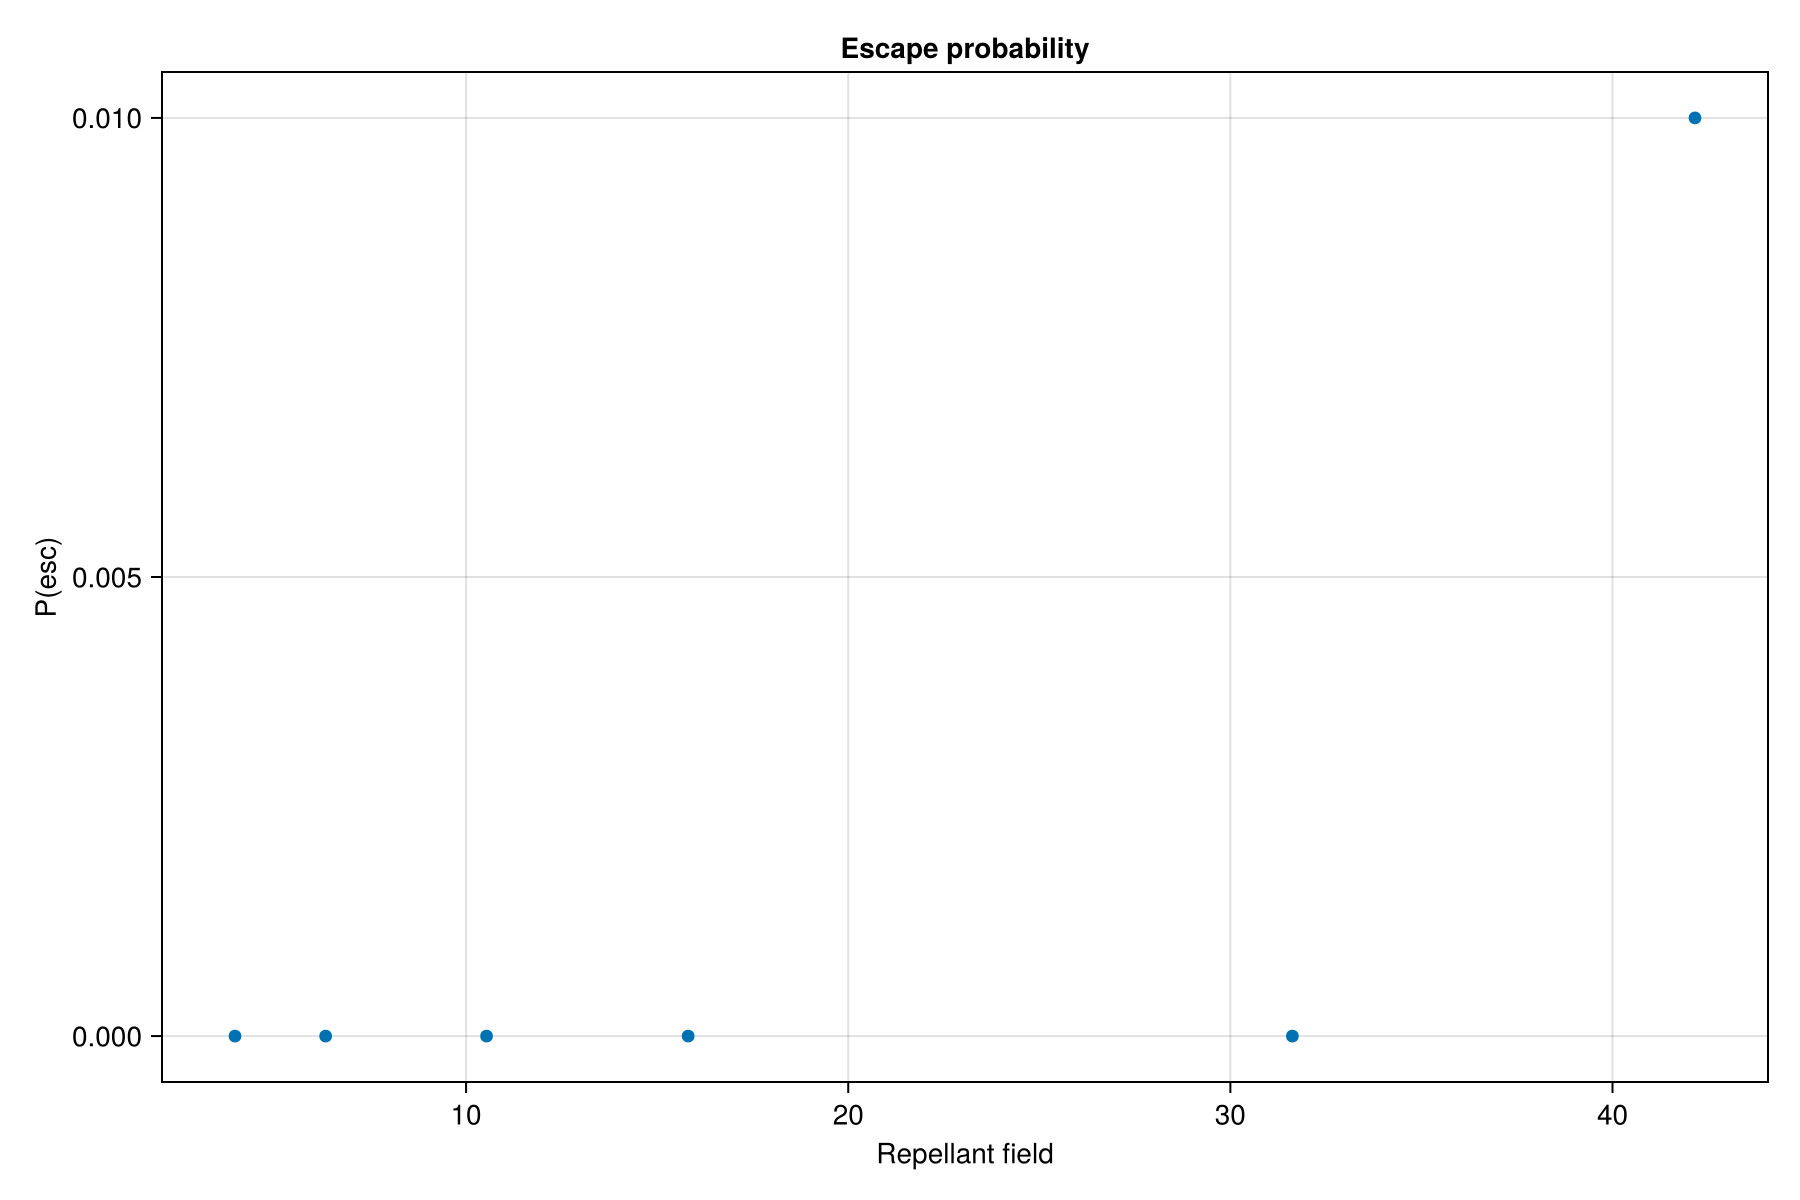

In [50]:
combinations = [ "p05_r75", "p05_r1", "p05_r2", "p05_r3", "p05_r5", "p05_r8"]

# combinations = ["p05", "p05_r025", "p075_r025", "p1_r025", "p2_r025"]

Dcvals_r = [ 13.33, 10.0, 5.0, 3.33, 2, 1.25]
dvals_r = [0.0075, 0.01, 0.02, 0.03, 0.05, 0.08]

p_esc = []
for i in 1:length(combinations)
    filename = "fsb_posneg_$(combinations[i]).jld2"
    counts = 0
    jldopen(filename, "r") do file
        g = file[@sprintf("step_%06d", 25000)]
        x = g["x"]
        y = g["y"]
        for agent in 1:500
            x1 = x[agent]
            y1 = y[agent]
            if x1 > 200 || y1 > 200 || x1 < -200 || y1 < -200
                counts += 1
            end
        end
    end
    push!(p_esc, (counts / 500))
    println("$(combinations[i]): $counts")
end

field_atr = []

for i in 1:length(combinations)
    Dc_a = Dcvals_r[i]
    d_a = dvals_r[i]
    l = sqrt(Dc_a / d_a)
    push!(field_atr, l)
end

fig = Figure(size = (900, 600))
ax = Axis(fig[1,1], title = "Escape probability", xlabel = "Repellant field", ylabel = "P(esc)")
scatter!(ax, field_atr, p_esc)
fig


In [41]:
save("Plots/Fixed_source_model/Posneg/P_esc_cluster_att.pdf", fig)

CairoMakie.Screen{PDF}


In [50]:
using Images, FileIO

# combinations = ["p05_r025", "p075_r025", "p1_r025", "p2_r025", "p3_r025", "p5_r025", "p8_r025"]
combinations = [ "p05_r75", "p05_r1", "p05_r2", "p05_r3", "p05_r5", "p05_r8"]

data = Dict{Int, Any}()
step = 25000
for i in 1:length(combinations)
    jldopen("fsb_posneg_$(combinations[i]).jld2", "r") do file
        key = file[@sprintf("step_%06d", step)]

        x = (copy(key["x"]))
        y = (copy(key["y"]))

        M = falses(401, 401)

        # convert to pixel coordinates
        xpix = round.(Int, x) .+ 201
        ypix = round.(Int, y) .+ 201

        # keep only valid indices
        valid = (1 .<= xpix .<= 401) .& (1 .<= ypix .<= 401)

        # apply filtering
        M[CartesianIndex.(ypix[valid], xpix[valid])] .= true

        coses = Gray.(M)
        # save image
        save("Fiji_images/input_posneg_2/image_$(combinations[i]).png", coses)
    end
end

In [52]:
using CSV, DataFrames

# combinations = ["p05_r025", "p075_r025", "p1_r025", "p2_r025", "p3_r025", "p5_r025", "p8_r025"]
combinations = [ "p05_r75", "p05_r1", "p05_r2", "p05_r3", "p05_r5", "p05_r8"]



results_2 = DataFrame(combi=String[], diameter=Float64[])
for i in 1:length(combinations)
            filename = "Fiji_images/output_posneg_2/image_$(combinations[i]).pngresults.csv"
            
            # read CSV
            df = CSV.read(filename, DataFrame)

            # extract MinFeret
            diameters = df.MinFeret

            # keep only unique values
            diameters_unique = unique(diameters)

            # append to results dataframe
            for d in diameters_unique
                if d > 5

                    push!(results_2, (combinations[i], d))
                end
            end
        end


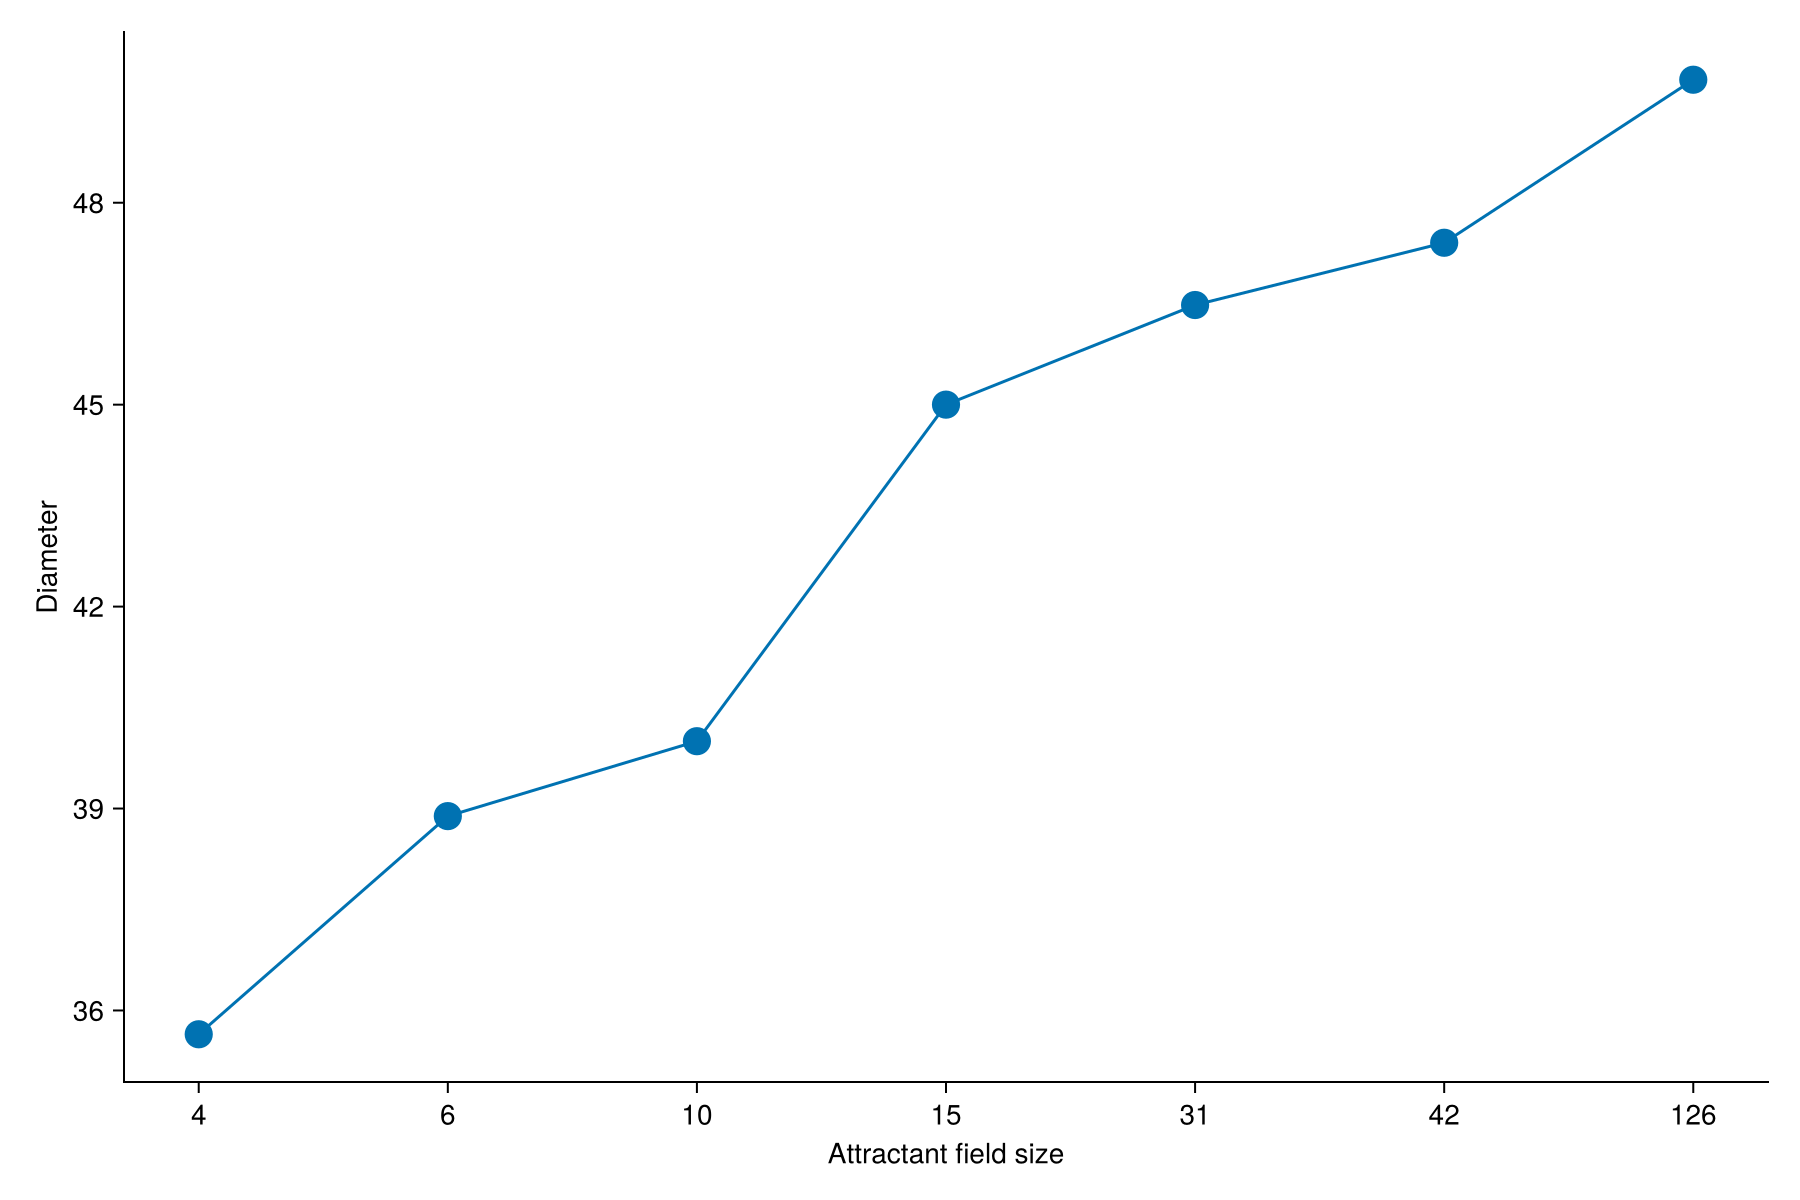

In [65]:
using CairoMakie

rep_field = ["4", "6", "10", "15", "31", "42", "126"]
combinations = ["p8_r025", "p5_r025","p3_r025", "p2_r025", "p1_r025","p075_r025",  "p05_r025" ]

diameters = []
for i in 1:length(combinations)
    row = results[results.combi .== combinations[i], :]
    d = maximum(row.diameter)
    push!(diameters, d)
end
fig = Figure(size = (900, 600))
ax = GLMakie.Axis(fig[1,1], xlabel = "Attractant field size", ylabel = "Diameter")
scatterlines!(ax, 1:length(combinations), diameters, markersize = 20)
ax.xticks = (1:length(combinations), rep_field)
ax.rightspinevisible = false
ax.topspinevisible = false
ax.xgridvisible = false
ax.ygridvisible = false
fig

In [66]:
save("Plots/Fixed_source_model/Posneg/Clust_size_repelant_field.pdf", fig)

CairoMakie.Screen{PDF}


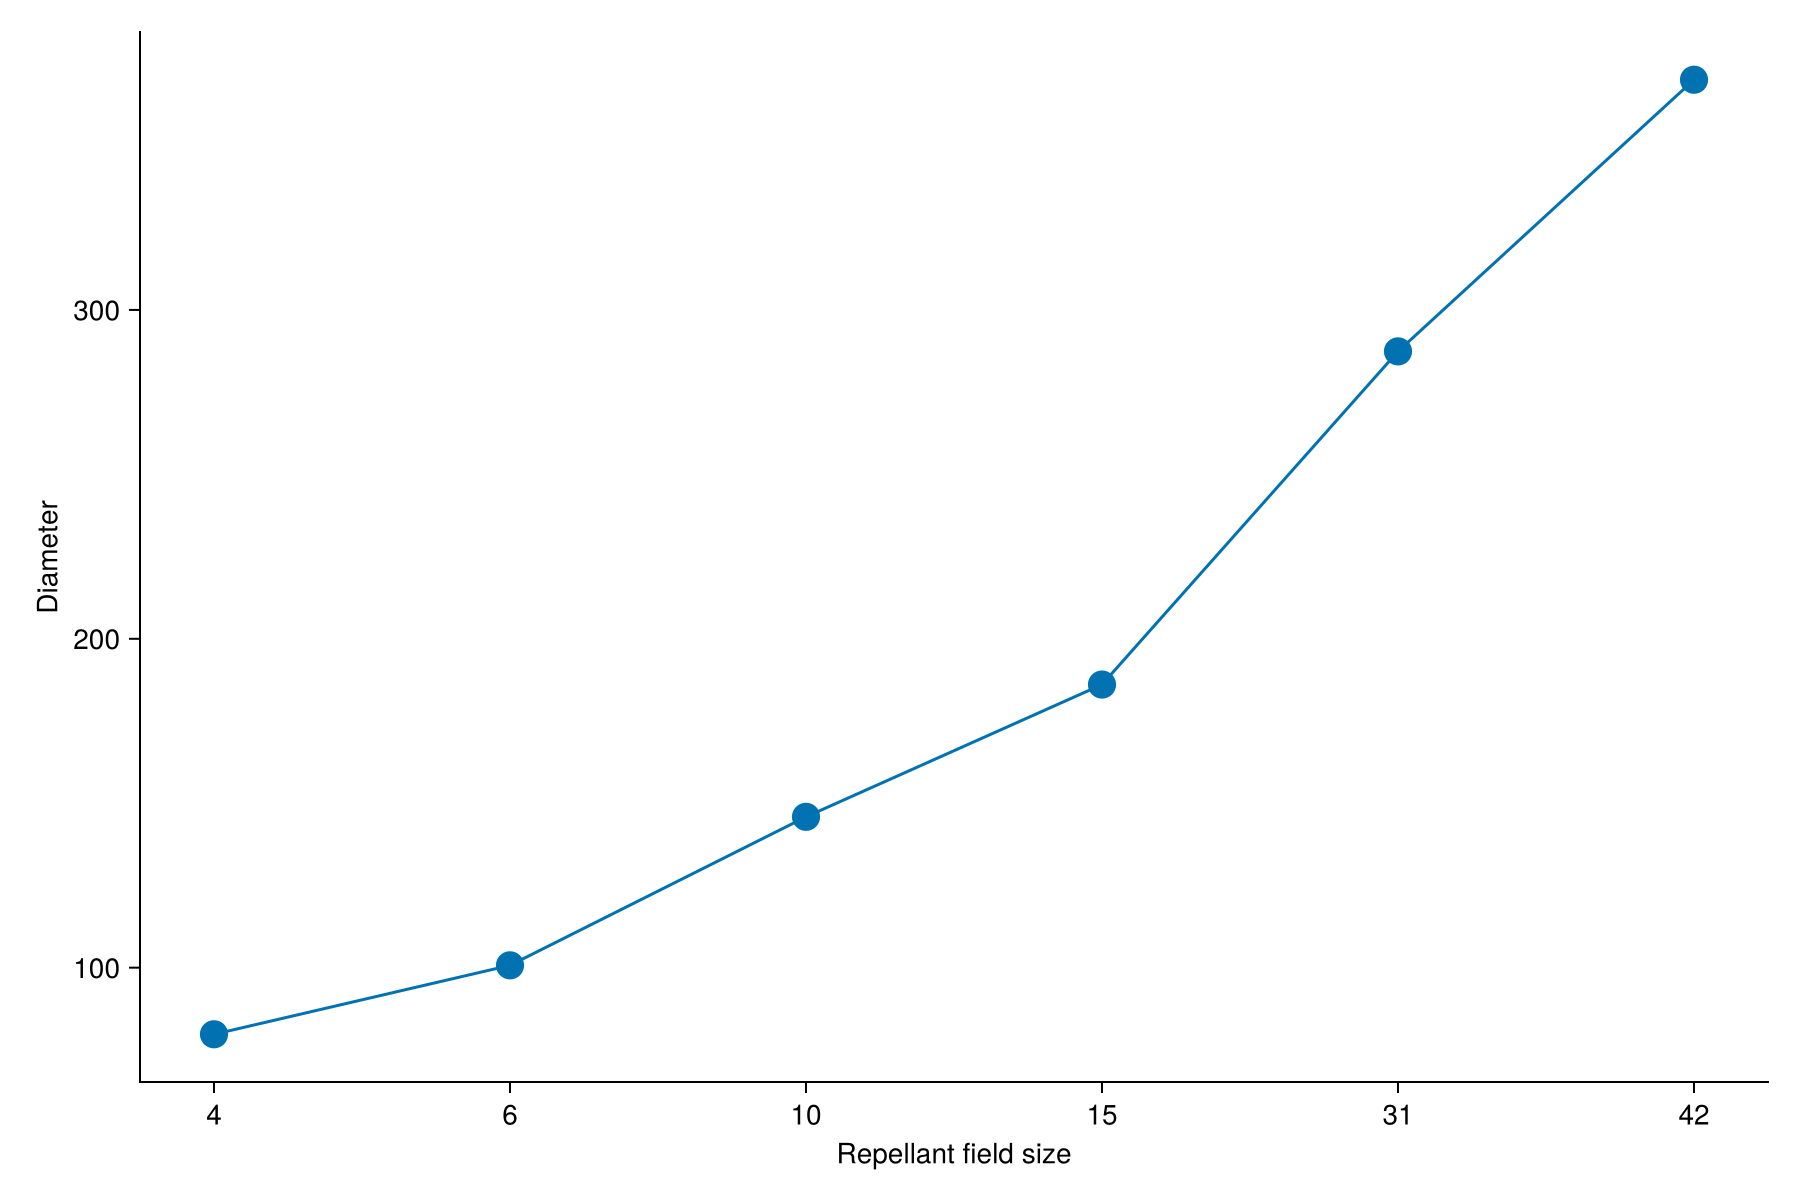

In [69]:
using CairoMakie

combinations = ["p05_r8", "p05_r5", "p05_r3", "p05_r2", "p05_r1", "p05_r75"]
# combinations = ["p05_r75", "p05_r1", "p05_r2", "p05_r3", "p05_r5", "p05_r8"]
rep_field = ["4", "6", "10", "15", "31", "42"]

diameters = []
for i in 1:length(combinations)
    row = results_2[results_2.combi .== combinations[i], :]
    d = maximum(row.diameter)
    push!(diameters, d)
end
fig = Figure(size = (900, 600))
ax = GLMakie.Axis(fig[1,1], xlabel = "Repellant field size", ylabel = "Diameter")
scatterlines!(ax, 1:length(combinations), diameters, markersize = 20)
ax.xticks = (1:length(combinations), rep_field)
ax.rightspinevisible = false
ax.topspinevisible = false
ax.xgridvisible = false
ax.ygridvisible = false
fig

In [71]:
save("Plots/Fixed_source_model/Posneg/ring_diam_rep_field.pdf", fig)

CairoMakie.Screen{PDF}


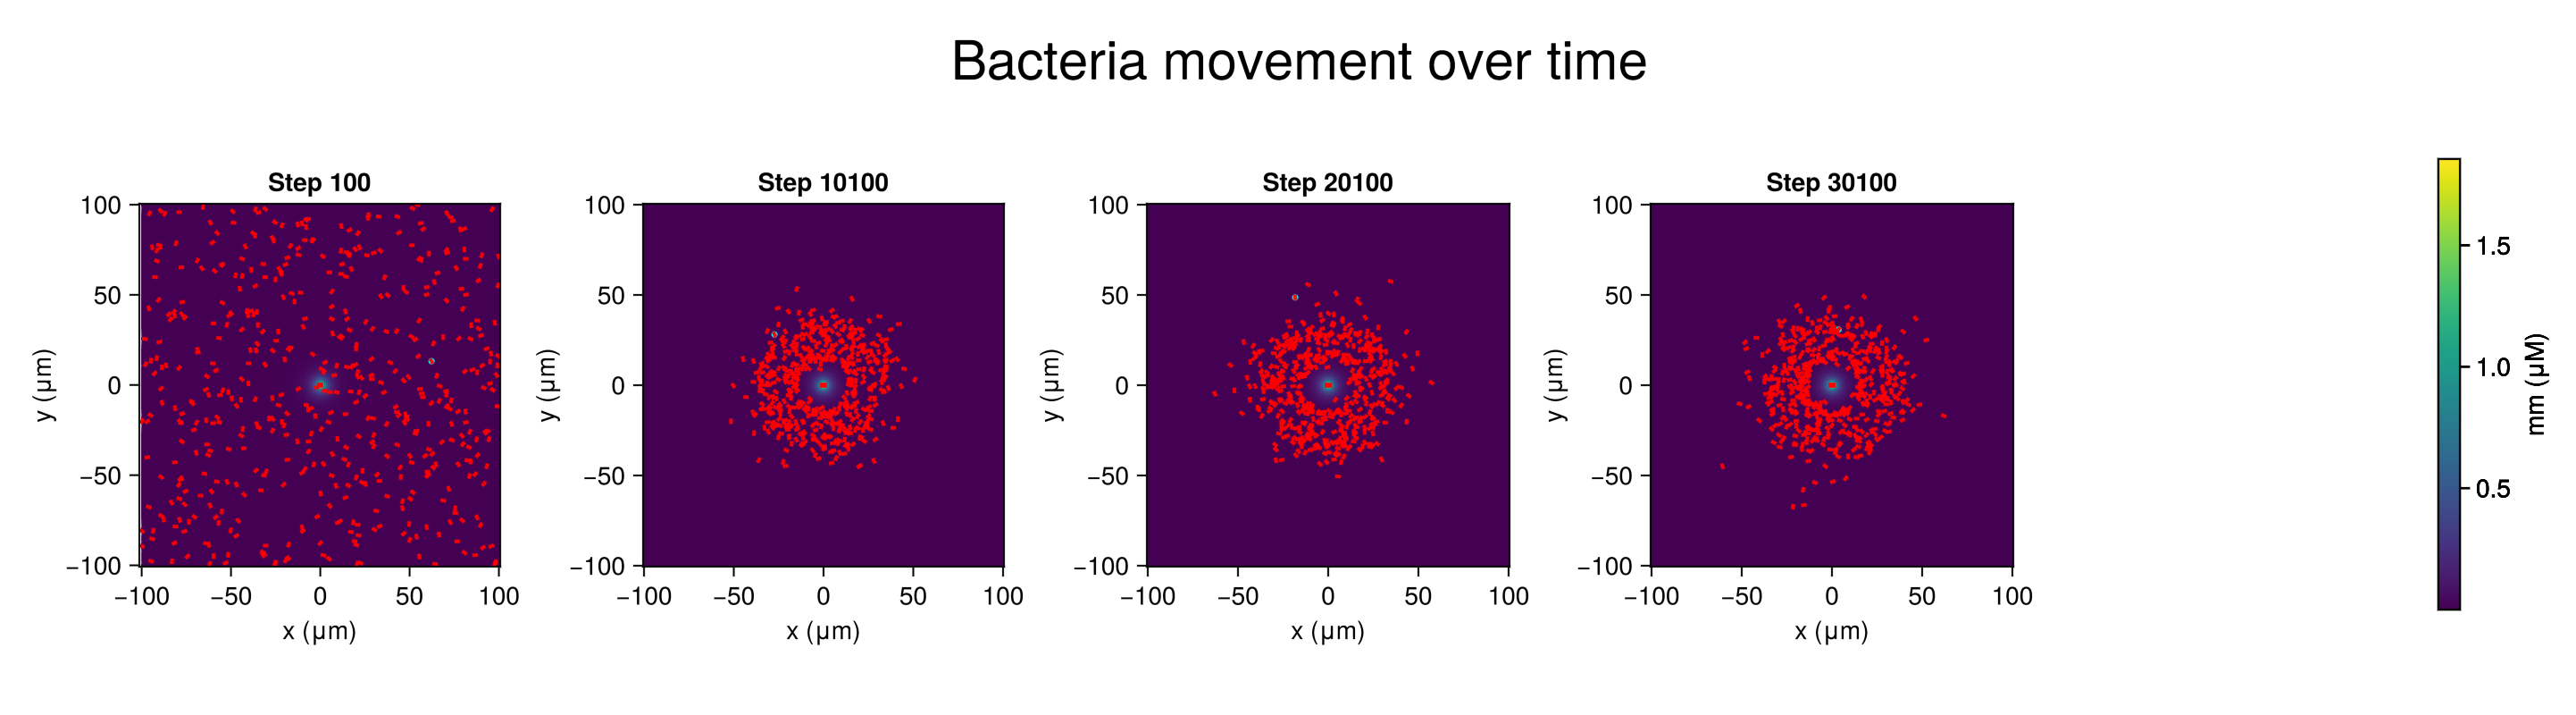

GLMakie.Screen(...)

In [6]:
fig2 = Figure(size=(2100,400))

model_steps = 100:100:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

xs, ys = 0.0, 0.0


len = Int(100 + 100)
# x_grid = range(com.simBox[1], com.simBox[3], length=len)
# y_grid = range(com.simBox[2], com.simBox[4], length=len)
x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(1.25 / 0.08)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

jldopen("fsb_posneg_test_2.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig2[1, 1*j-1], aspect=1, title="Step $step",  xlabel="x (μm)", ylabel="y (μm)")

        g = file[@sprintf("step_%06d", step)]

        hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)
        Colorbar(fig2[1, 5], hm, label="mm (μM)")


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

    end
end
# sideinfo = Label(fig2[2, 1:5], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
supertitle  = Label(fig2[0, :], "Bacteria movement over time", fontsize = 30)

display(fig2)

In [7]:
save("Plots/Fixed_source_model/Posneg/test_1_pos_n05.png", fig2)

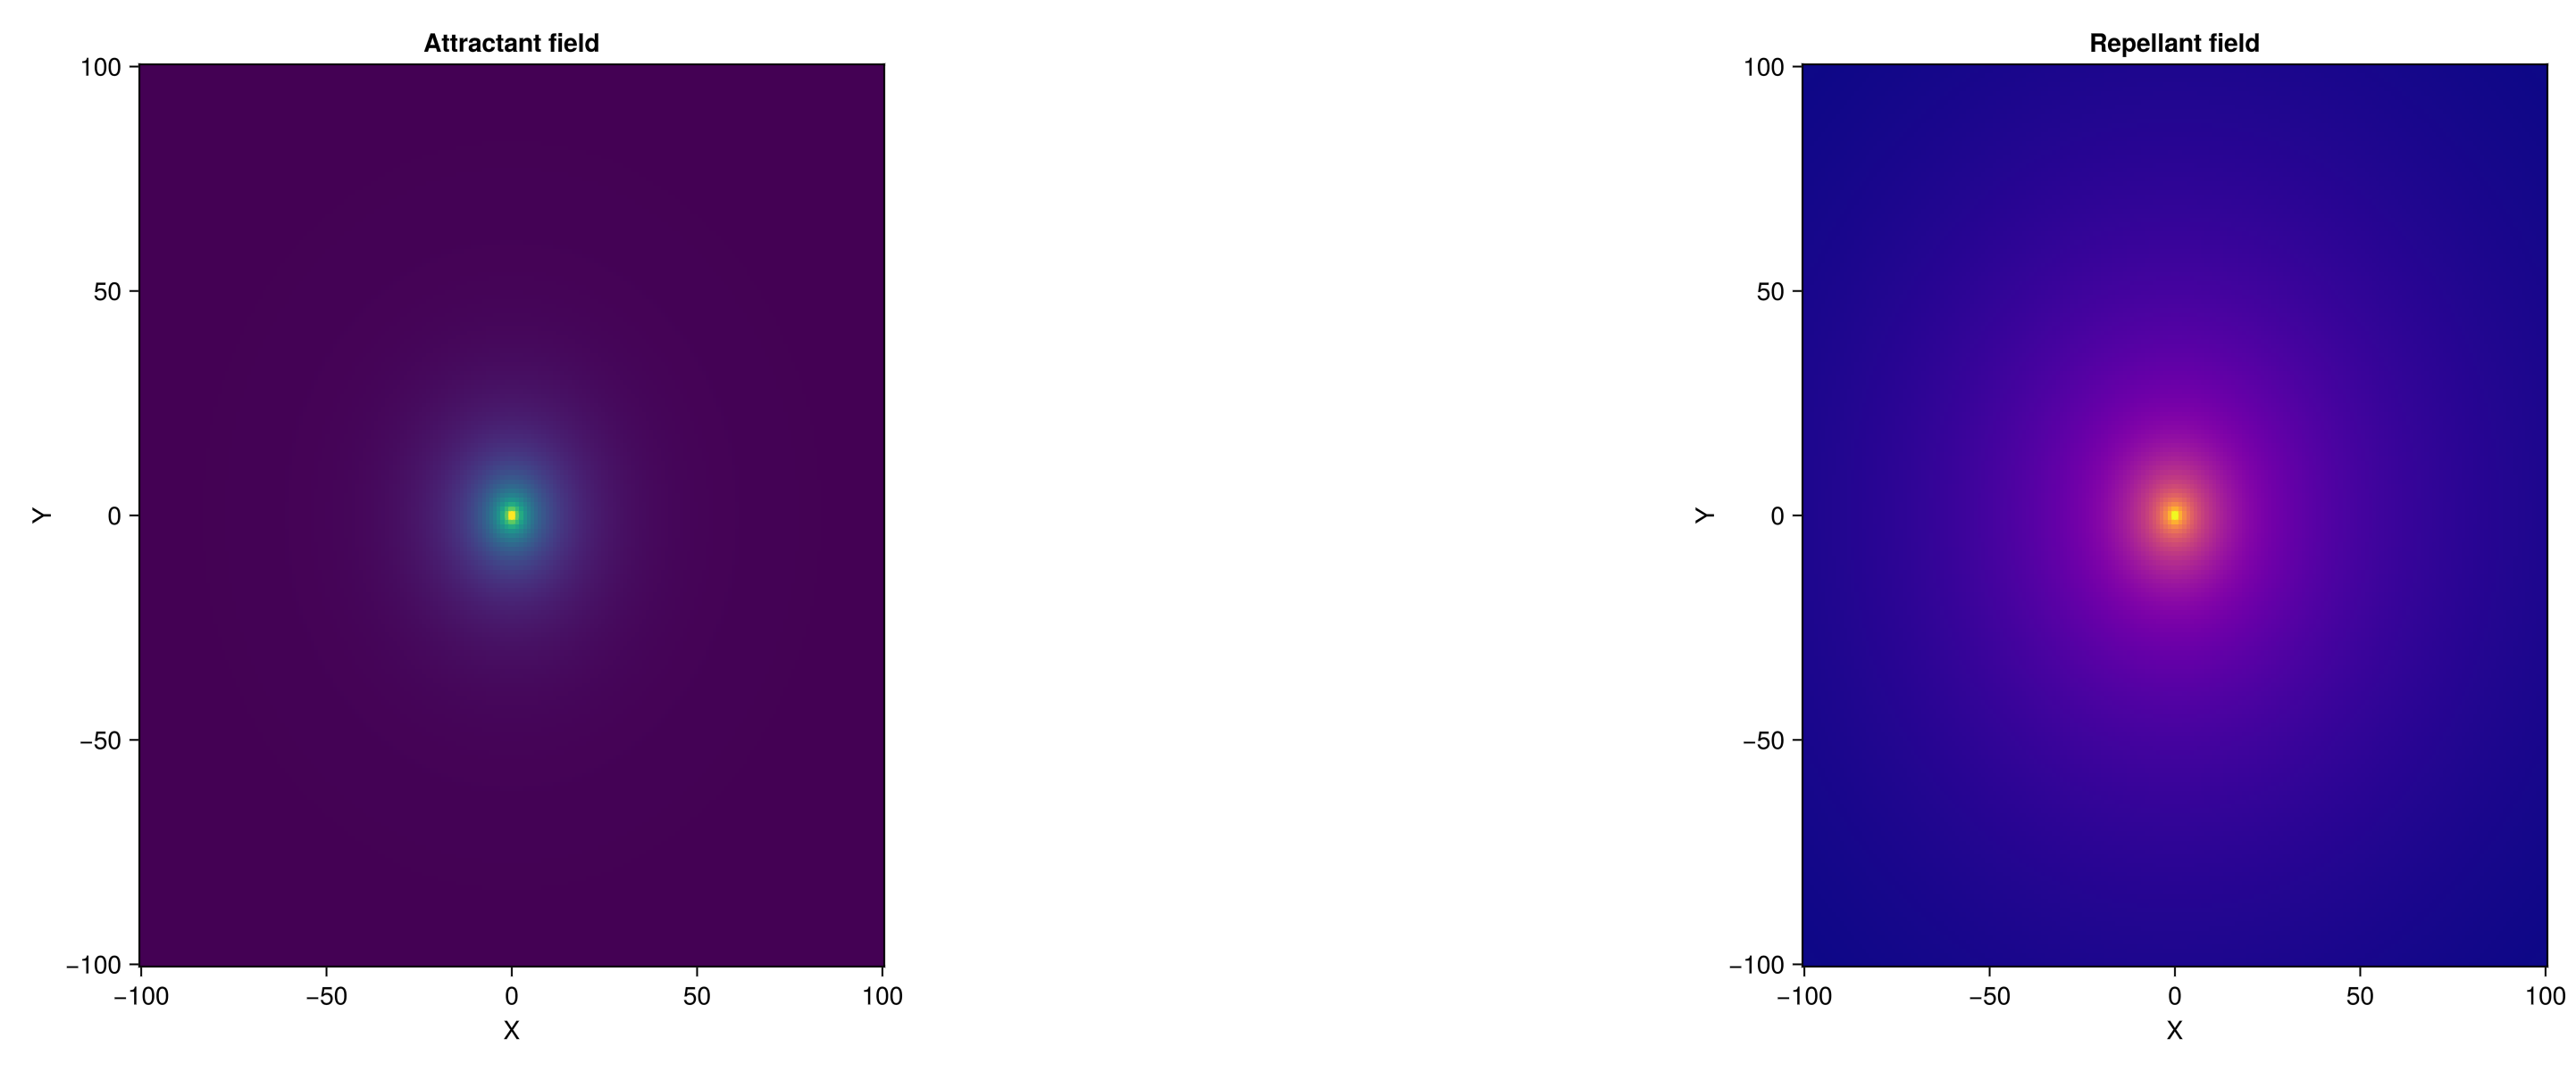

In [13]:
fig = Figure(size=(1800, 600))
ax = Axis(fig[1,1], title = "Attractant field", xlabel = "X", ylabel = "Y")
ax_1 = Axis(fig[1,3], title = "Repellant field", xlabel = "X", ylabel = "Y")

xs, ys = 0.0, 0.0
len = Int(100 + 100)

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(5 / 0.02)
λ_1 = sqrt(20 / 0.005)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)
mm_grid_1 = @. 1.0 * besselk(0, r / λ_1)

hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)
Colorbar(fig2[1, 2], hm, label="mm (μM)")

hm_1 = heatmap!(ax_1, x_grid, y_grid, mm_grid_1, colormap=:plasma)
Colorbar(fig2[1, 4], hm, label="mm (μM)")

fig

In [ ]:
save("Plots/Fixed_source_model/Posneg/fields_a2_r05.png", fig)

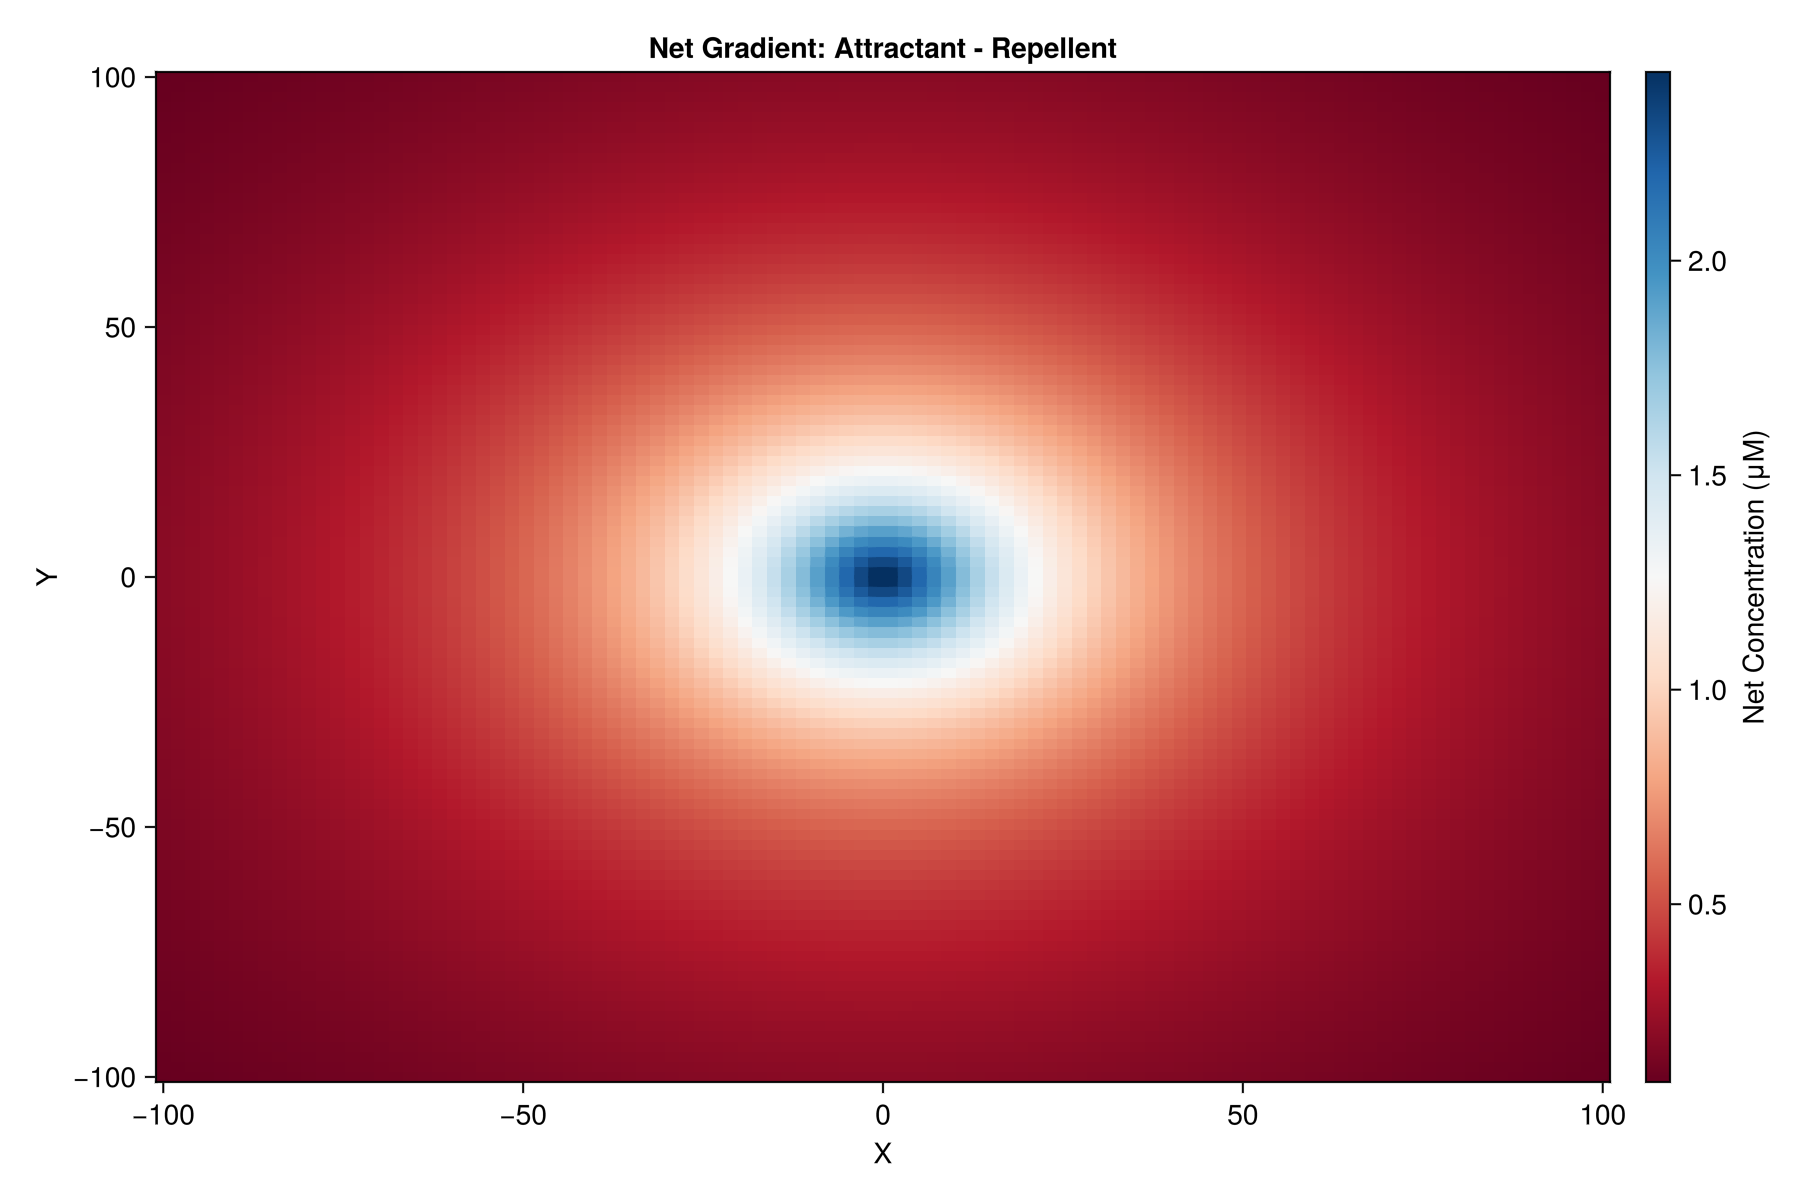

In [20]:
# Setup Figure
fig = Figure(size=(900, 600))

# Define Grid
len = 100
x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)
X, Y = meshgrid(x_grid, y_grid)

# Parameters
xs, ys = 0.0, 0.0
λ_1 = sqrt(1.67 / 0.06)    
λ = sqrt(20 / 0.005)  

# Calculate Fields
r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)
mm_attractant = @. 1.0 * besselk(0, r / λ)
mm_repellant = @. 1.0 * besselk(0, r / λ_1)

# Calculate Difference
mm_diff = mm_attractant .- mm_repellant

# Plot Difference
ax = Axis(fig[1, 1], 
          title = "Net Gradient: Attractant - Repellent", 
          xlabel = "X", 
          ylabel = "Y")

hm = heatmap!(ax, x_grid, y_grid, mm_diff, colormap=:RdBu)
cb = Colorbar(fig[1, 2], hm, label="Net Concentration (μM)")

# Optional: Add a contour for the zero-crossing (neutral zone)
contour!(ax, x_grid, y_grid, mm_diff, levels=[0.0], linewidth=2, color=:white)

fig

In [21]:
save("Plots/Fixed_source_model/Posneg/net_field_a05_r6.png", fig)

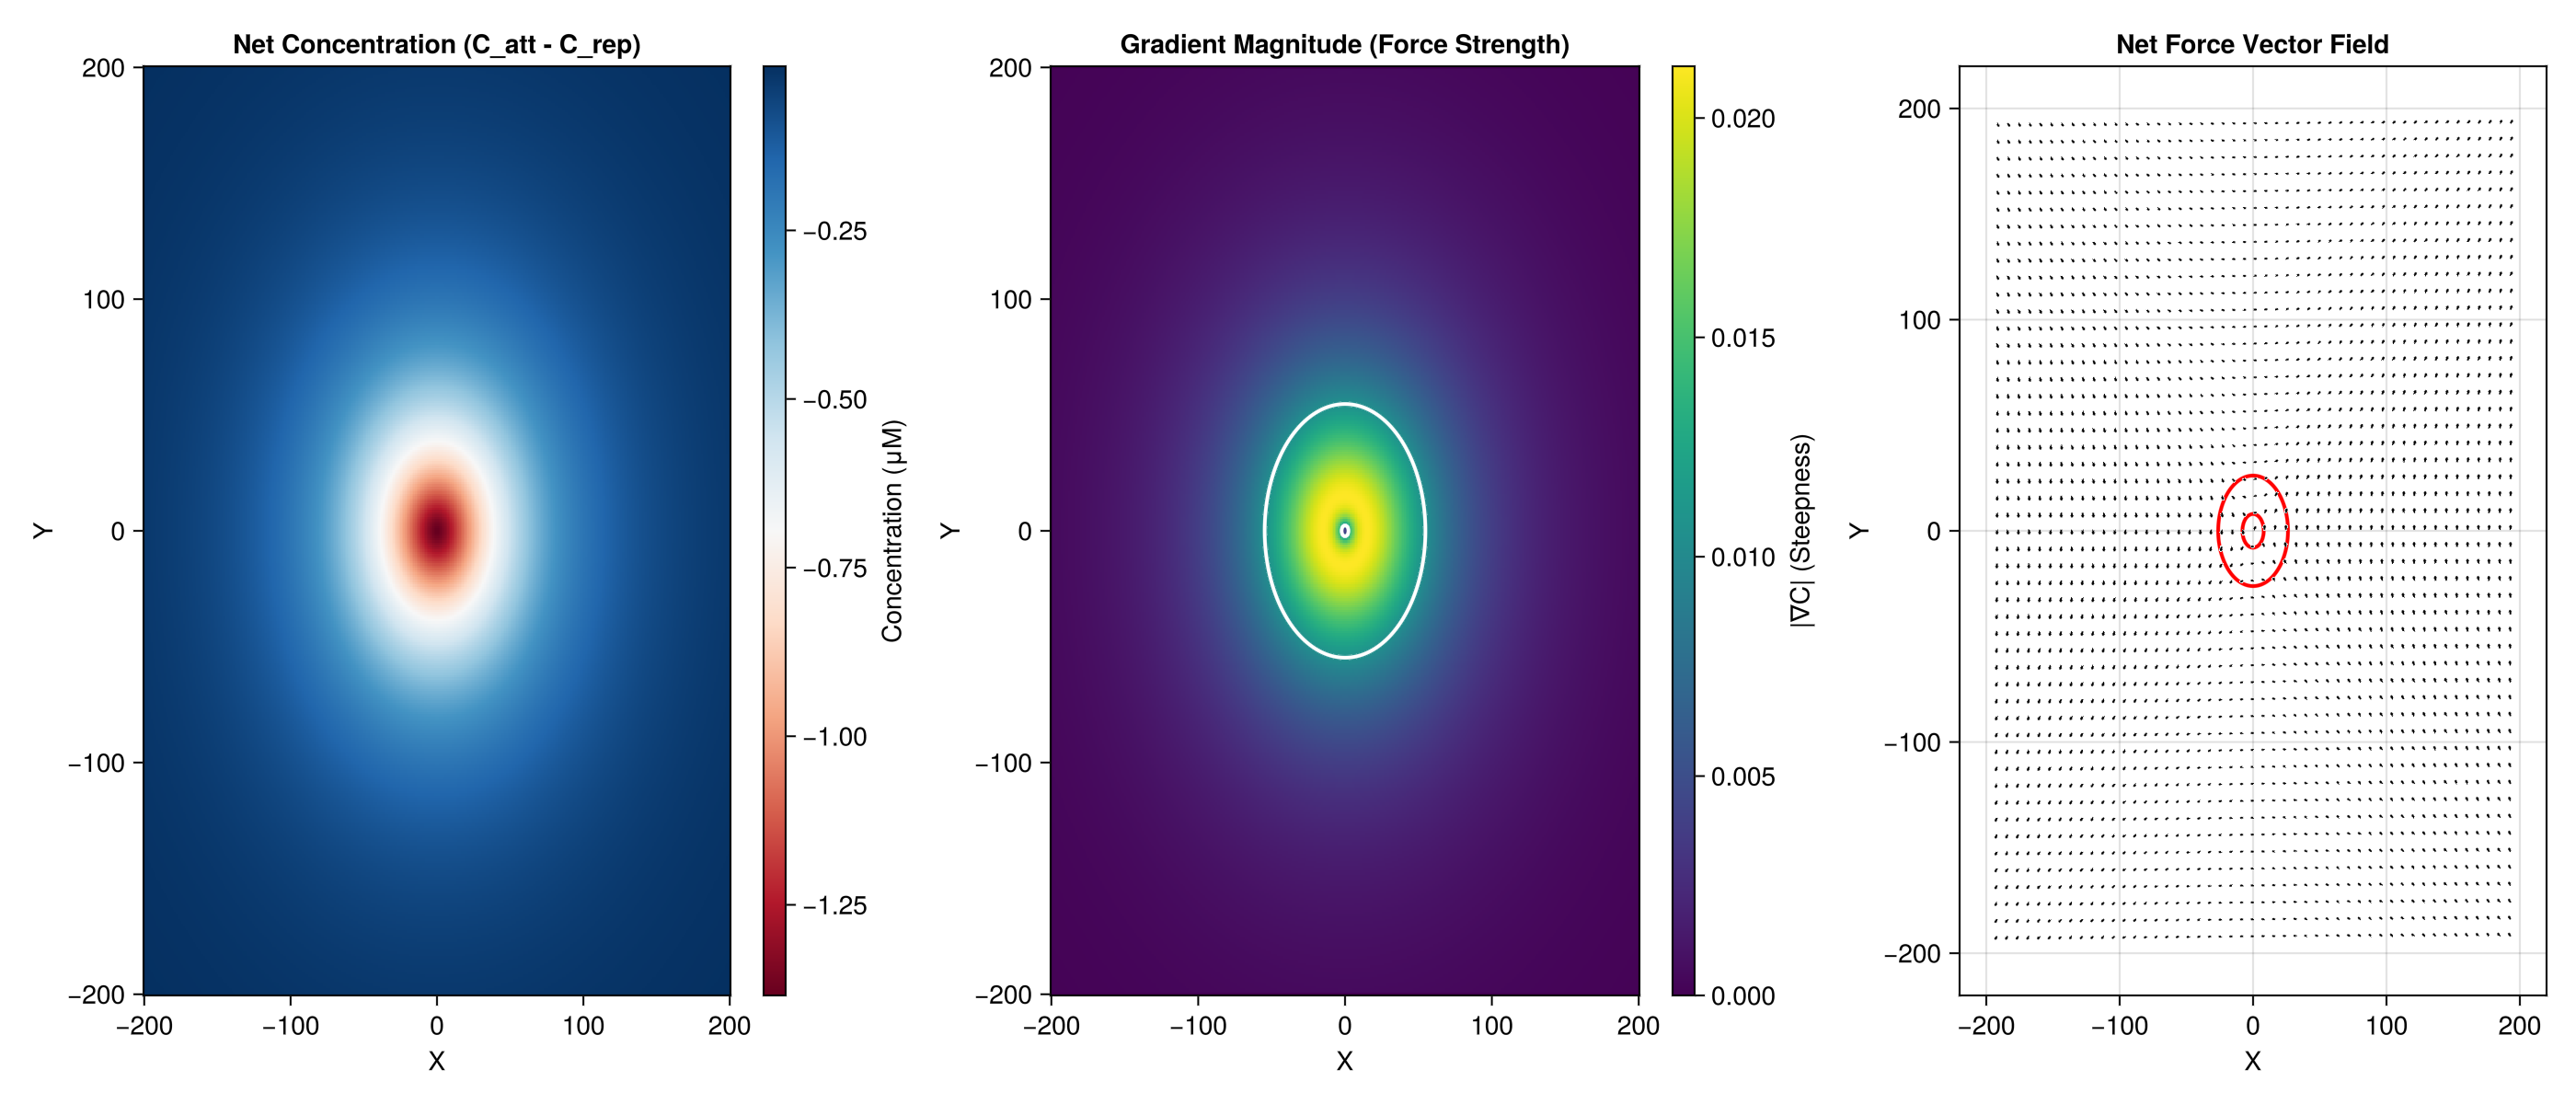

In [39]:
# --- Setup ---
fig = Figure(size=(1400, 600))

# Grid
len = 400 # Higher resolution for gradients
x_grid = range(-200, 200, length=len)
y_grid = range(-200, 200, length=len)
X, Y = meshgrid(x_grid, y_grid)

# Parameters
xs, ys = 0.0, 0.0
λ = sqrt(5 / 0.02)      # Attractant decay
λ_1 = sqrt(20 / 0.005)  # Repellent decay

# --- 1. Concentration Fields ---
r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)
C_att = @. 1.0 * besselk(0, r / λ)
C_rep = @. 1.0 * besselk(0, r / λ_1)
C_net = C_att .- C_rep

# --- 2. Calculate Gradient (The "Force") ---
# Numerical gradient: ∂C/∂x and ∂C/∂y
dx = x_grid[2] - x_grid[1]
dy = y_grid[2] - y_grid[1]

# Using central differences for better accuracy (skip edges)
dCdx = similar(C_net)
dCdy = similar(C_net)

# Manual gradient calculation (avoiding boundaries for simplicity)
for i in 2:(len-1), j in 2:(len-1)
    dCdx[i, j] = (C_net[i+1, j] - C_net[i-1, j]) / (2*dx)
    dCdy[i, j] = (C_net[i, j+1] - C_net[i, j-1]) / (2*dy)
end

# Gradient Magnitude (Scalar)
grad_mag = sqrt.(dCdx.^2 .+ dCdy.^2)

# --- Plotting ---

# Panel 1: Net Concentration (Difference)
ax1 = Axis(fig[1, 1], title="Net Concentration (C_att - C_rep)", xlabel="X", ylabel="Y")
hm1 = heatmap!(ax1, x_grid, y_grid, C_net, colormap=:RdBu)
Colorbar(fig[1, 2], hm1, label="Concentration (μM)")

# Panel 2: Gradient Magnitude (Where bacteria move/stop)
ax2 = Axis(fig[1, 3], title="Gradient Magnitude (Force Strength)", xlabel="X", ylabel="Y")
hm2 = heatmap!(ax2, x_grid, y_grid, grad_mag, colormap=:viridis)
Colorbar(fig[1, 4], hm2, label="|∇C| (Steepness)")

contour!(ax2, x_grid, y_grid, grad_mag, levels=[maximum(grad_mag) * 0.5], linewidth=2, color=:white)

# Panel 3: Vector Field (Direction of Force)
ax3 = Axis(fig[1, 5], title="Net Force Vector Field", xlabel="X", ylabel="Y")

# Downsample grid for arrows
# Use 'len' (the length of the grid) to define the step
step = 8
# Create a range of indices: 1, 9, 17, ... up to len
indices = 1:step:len

# CRITICAL FIX: Index the 2D arrays (X, Y, dCdx, dCdy)
# Do NOT index x_grid or y_grid directly here
x_sub = X[indices, indices]
y_sub = Y[indices, indices]
u_sub = dCdx[indices, indices]
v_sub = dCdy[indices, indices]

# Plot arrows
arrows2d!(ax3, x_sub, y_sub, u_sub, v_sub, lengthscale = 2, normalize = true)

# Highlight the "Ring" (max gradient)
max_grad = maximum(grad_mag)
if max_grad > 0
    contour!(ax3, x_grid, y_grid, grad_mag, levels=[max_grad * 0.9], linewidth=2, color=:red)
end

fig